# Runtime Curve Walkthrough: Flood x Solar

This notebook is a runnable walkthrough of the canonical `flood_solar` damage-curve artifact.

It is intentionally **M3-only**:

1. Read the canonical runtime JSON artifact.
2. Inspect the failure-unit coverage and damage-code contract.
3. Evaluate the piecewise flood damage curves.
4. Demonstrate the local-depth transform: `h_i = max(0, WSE - z_i_crit)`.
5. Assemble conditional loss if inundated from explicit value/exposure inputs.

It does **not** calculate flood occurrence probability, event frequency, EAL, PML, VaR, or TVaR. Those belong downstream in the Hazard modeling tier.


## Why Flood Is Different From Hail

Hail x solar v1 had one primary nonzero failure-unit: PV module glass/cell breakage.

Flood x solar is different. The same flood event can affect different equipment at different elevations and through different pathways:

```text
water surface elevation
  -> local depth at inverter cabinet
  -> local depth at switchgear
  -> local depth at transformer controls
  -> local depth at combiner / SCADA / cable pathway
  -> module lower-edge submersion
  -> velocity/scour proxy for foundations
```

So the runtime object is naturally multi-failure-unit. The consumer assembles loss by summing:

```text
loss_total_if_event = sum_i DR_i(local_intensity_i) * value_i * fraction_value_exposed_i
```


In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

pd.set_option("display.max_colwidth", 140)
pd.set_option("display.width", 180)

plt.rcParams.update({
    "figure.figsize": (10, 6),
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


def find_repo_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "AGENTS.md").exists() and (candidate / "docs/damage_curves").exists():
            return candidate
    raise RuntimeError("Could not find damage_modeling repo root from current working directory.")


REPO_ROOT = find_repo_root(Path.cwd())
CELL_DIR = REPO_ROOT / "docs/damage_curves/damage_curve_implementation/DAMAGE_CURVE_LIBRARY_V2_5_IMPLEMENTATION_HARDENED_DELIVERABLE/01_cells/flood_solar/current"
ARTIFACT_PATH = CELL_DIR / "flood_solar__model_v1_0__docs_r3__curve_artifact.json"
DOSSIER_PATH = CELL_DIR / "flood_solar_curve_derivation_dossier_v1_0.md"
OUTPUT_DIR = REPO_ROOT / "notebooks/flood/solar/outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

with ARTIFACT_PATH.open("r", encoding="utf-8") as f:
    artifact = json.load(f)

assert artifact["canonical_runtime_artifact"] is True

print(f"repo root: {REPO_ROOT}")
print(f"artifact : {ARTIFACT_PATH.relative_to(REPO_ROOT)}")
print(f"outputs  : {OUTPUT_DIR.relative_to(REPO_ROOT)}")


repo root: /Users/divy/code/work/infrasure_git_codes/damage_modeling
artifact : docs/damage_curves/damage_curve_implementation/DAMAGE_CURVE_LIBRARY_V2_5_IMPLEMENTATION_HARDENED_DELIVERABLE/01_cells/flood_solar/current/flood_solar__model_v1_0__docs_r3__curve_artifact.json
outputs  : notebooks/flood/solar/outputs


## 1. Load The Canonical Runtime Artifact

The JSON artifact is the runtime contract. The dossier and workbook explain the derivation; the runtime consumer should pin the JSON.


In [2]:
identity_fields = [
    "schema_version",
    "cell_id",
    "damage_code_id",
    "semantic_damage_model_version",
    "documentation_revision",
    "package_release",
    "canonical_runtime_artifact",
    "source_dossier",
    "source_workbook",
]
identity = pd.DataFrame([{"field": field, "value": artifact.get(field)} for field in identity_fields])
display(identity)

hazard_axis = pd.DataFrame([artifact["hazard_axis"]])
display(Markdown("**Hazard axis / axis bridge**"))
display(hazard_axis)


,field,value
0,schema_version,damage_curve_record_bundle.v1
1,cell_id,flood_solar
2,damage_code_id,FLOOD_SOLAR_ELECTRICAL_INUNDATION_V1
3,semantic_damage_model_version,model v1.0
4,documentation_revision,docs r3
5,package_release,library v2.5
6,canonical_runtime_artifact,True
7,source_dossier,01_cells/flood_solar/current/flood_solar_curve_derivation_dossier_v1_0.md
8,source_workbook,01_cells/flood_solar/current/damage_curve_records_v1_0_flood_solar.xlsx


**Hazard axis / axis bridge**

,id,input_field_preferred,fallback_input_field,internal_axis,formula,unit,valid_range,extrapolation_policy
0,FLOOD_LOCAL_DEPTH_COMPONENT_DATUM,water_surface_elevation_m,site_flood_depth_m,local_depth_above_component_datum_m,"h_i = max(0, WSE - z_i_crit)",m,"[0, 2.0]",clamp_or_warn


## 2. Failure-Unit Coverage

Flood x solar is not one generic plant-level curve. It has eight failure-unit records.

The practical meaning: each failure-unit can have its own local intensity, curve, value bucket, and exposure fraction.


,id,subsystem,component,treatment,axis,y_axis,f_kind
0,FS_INV,INVERTER_SYSTEM,INVERTER,primary_nonzero,local_depth_above_component_datum_m,failure_unit_damage_ratio,site_geometry
1,FS_SWG,SUBSTATION,SWITCHGEAR,primary_nonzero,local_depth_above_component_datum_m,failure_unit_damage_ratio,site_geometry
2,FS_XFMR,SUBSTATION,TRANSFORMER_MAIN,primary_nonzero,local_depth_above_component_datum_m,failure_unit_damage_ratio,site_geometry
3,FS_COMB,INVERTER_SYSTEM,COMBINER_BOX + DC_PROTECTION,primary_secondary,local_depth_above_component_datum_m,failure_unit_damage_ratio,site_geometry
4,FS_SCADA,SCADA,MONITORING_SYSTEM,secondary,local_depth_above_component_datum_m,failure_unit_damage_ratio,site_geometry
5,FS_CABLE,ELECTRICAL_COLLECTION,CABLE_AC + CABLE_DC,conditional_secondary,depth_pathway_termination_exposure,failure_unit_damage_ratio,site_geometry
6,FS_PVMOD,PV_ARRAY,PV_MODULE,conditional_secondary,depth_above_module_lower_edge_m,failure_unit_damage_ratio,site_geometry
7,FS_FOUND,FOUNDATION,FOUNDATION_BASE,conditional_secondary,flow_velocity_or_scour_proxy,failure_unit_damage_ratio,site_geometry


**Coverage summary**

,treatment,axis,count
0,conditional_secondary,depth_above_module_lower_edge_m,1
1,conditional_secondary,depth_pathway_termination_exposure,1
2,conditional_secondary,flow_velocity_or_scour_proxy,1
3,primary_nonzero,local_depth_above_component_datum_m,3
4,primary_secondary,local_depth_above_component_datum_m,1
5,secondary,local_depth_above_component_datum_m,1


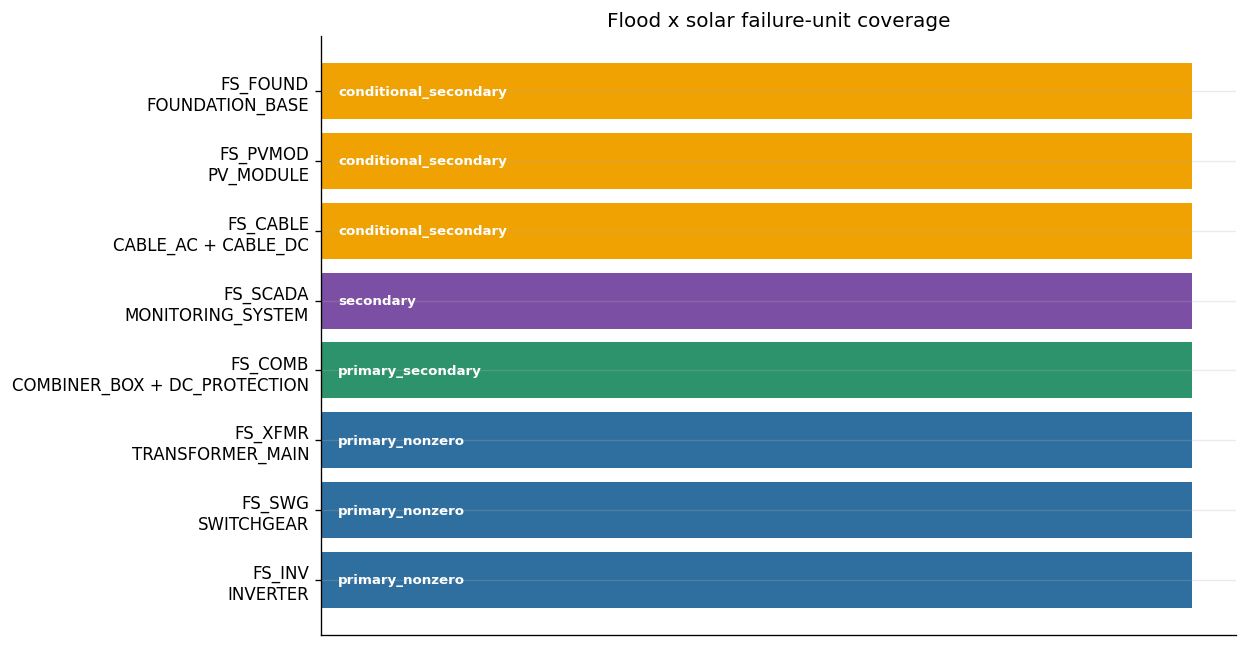

In [3]:
failure_units = pd.DataFrame(artifact["failure_units"])
display(failure_units)

coverage = failure_units.groupby(["treatment", "axis"]).size().reset_index(name="count")
display(Markdown("**Coverage summary**"))
display(coverage)

fig, ax = plt.subplots(figsize=(10.5, 5.5))
plot_units = failure_units.copy()
plot_units["label"] = plot_units["id"] + "\n" + plot_units["component"]
colors = {
    "primary_nonzero": "#2f6f9f",
    "primary_secondary": "#2d936c",
    "secondary": "#7b4fa3",
    "conditional_secondary": "#f0a202",
}
ax.barh(plot_units["label"], [1] * len(plot_units), color=[colors.get(t, "#999") for t in plot_units["treatment"]])
ax.set_title("Flood x solar failure-unit coverage")
ax.set_xticks([])
ax.set_xlabel("")
for y, (_, row) in enumerate(plot_units.iterrows()):
    ax.text(0.02, y, row["treatment"], va="center", ha="left", color="white", fontweight="bold", fontsize=8)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "01_failure_unit_coverage.png", dpi=180, bbox_inches="tight")
plt.show()


## 3. Runtime Evaluation Helpers

The shipped curves are piecewise-linear state/depth curves, not logistics.

That choice matters: flood damage is often threshold/state-like around water entry, electrical evaluation/replacement, control cabinet inundation, and submersion. Interpolation is more auditable here than a smooth fragility curve.


In [4]:
curve_records = pd.DataFrame([
    {
        "curve_id": rec["curve_id"],
        "failure_unit_id": rec["failure_unit_id"],
        "curve_form": rec["curve_form"],
        "x_axis": rec["x_axis"],
        "n_points": len(rec["parameters"]["points"]),
    }
    for rec in artifact["curve_records"]
])
display(curve_records)

curve_by_id = {rec["curve_id"]: rec for rec in artifact["curve_records"]}
curve_by_failure_unit = {rec["failure_unit_id"]: rec for rec in artifact["curve_records"]}
failure_unit_by_id = {fu["id"]: fu for fu in artifact["failure_units"]}


def piecewise_dr(x, points):
    """Evaluate a piecewise-linear DR curve with endpoint clamping."""
    pts = np.asarray(points, dtype=float)
    xs = pts[:, 0]
    ys = pts[:, 1]
    return np.interp(np.asarray(x, dtype=float), xs, ys, left=ys[0], right=ys[-1])


def local_depth_from_wse(water_surface_elevation_m, component_critical_elevation_m):
    """Preferred axis bridge: local depth above component datum."""
    return max(0.0, float(water_surface_elevation_m) - float(component_critical_elevation_m))


def local_depth_from_site_depth(site_flood_depth_m, component_height_above_grade_m):
    """Fallback axis bridge when only site depth above grade is available."""
    return max(0.0, float(site_flood_depth_m) - float(component_height_above_grade_m))


def evaluate_failure_unit(failure_unit_id, local_intensity):
    rec = curve_by_failure_unit[failure_unit_id]
    dr = float(piecewise_dr(local_intensity, rec["parameters"]["points"]))
    return {
        "failure_unit_id": failure_unit_id,
        "curve_id": rec["curve_id"],
        "x_axis": rec["x_axis"],
        "local_intensity": float(local_intensity),
        "failure_unit_damage_ratio": dr,
    }


def evaluate_scenario(asset_rows, water_surface_elevation_m=None, site_flood_depth_m=None, flow_velocity_mps=None):
    """Evaluate all failure units for an illustrative asset substrate.

    asset_rows must provide value_usd and fraction_value_exposed. Depth-driven rows need either
    component_critical_elevation_m with WSE, or component_height_above_grade_m with site depth.
    Foundation/scour rows use flow_velocity_mps.
    """
    out = []
    for row in asset_rows:
        fu_id = row["failure_unit_id"]
        rec = curve_by_failure_unit[fu_id]
        x_axis = rec["x_axis"]
        if "flow_velocity" in x_axis or "scour" in x_axis:
            if flow_velocity_mps is None:
                raise ValueError(f"{fu_id} requires flow_velocity_mps")
            local_intensity = float(flow_velocity_mps)
        elif water_surface_elevation_m is not None and "component_critical_elevation_m" in row:
            local_intensity = local_depth_from_wse(water_surface_elevation_m, row["component_critical_elevation_m"])
        elif site_flood_depth_m is not None and "component_height_above_grade_m" in row:
            local_intensity = local_depth_from_site_depth(site_flood_depth_m, row["component_height_above_grade_m"])
        else:
            raise ValueError(f"{fu_id} needs elevation metadata for local-depth evaluation")
        evaluated = evaluate_failure_unit(fu_id, local_intensity)
        value = float(row["value_usd"])
        exposed = float(row["fraction_value_exposed"])
        evaluated.update({
            "subsystem": failure_unit_by_id[fu_id]["subsystem"],
            "component": failure_unit_by_id[fu_id]["component"],
            "value_usd": value,
            "fraction_value_exposed": exposed,
            "conditional_loss_if_event_usd": evaluated["failure_unit_damage_ratio"] * value * exposed,
            "metadata_note": row.get("metadata_note", ""),
        })
        out.append(evaluated)
    return pd.DataFrame(out)


,curve_id,failure_unit_id,curve_form,x_axis,n_points
0,FS_INV,FS_INV,piecewise_linear,local_depth_above_component_datum_m,9
1,FS_SWG,FS_SWG,piecewise_linear,local_depth_above_component_datum_m,9
2,FS_XFMR,FS_XFMR,piecewise_linear,local_depth_above_component_datum_m,9
3,FS_COMB,FS_COMB,piecewise_linear,local_depth_above_component_datum_m,9
4,FS_SCADA,FS_SCADA,piecewise_linear,local_depth_above_component_datum_m,9
5,FS_CABLE,FS_CABLE,piecewise_linear,depth_pathway_termination_exposure,9
6,FS_PVMOD,FS_PVMOD,piecewise_linear,depth_above_module_lower_edge_m,9
7,FS_FOUND,FS_FOUND,piecewise_linear,flow_velocity_mps_or_scour_proxy,7


## 4. Plot The Piecewise Runtime Curves

Depth-driven equipment curves are plotted against local depth above the relevant component datum. The foundation curve is plotted separately because its axis is velocity/scour proxy, not depth.


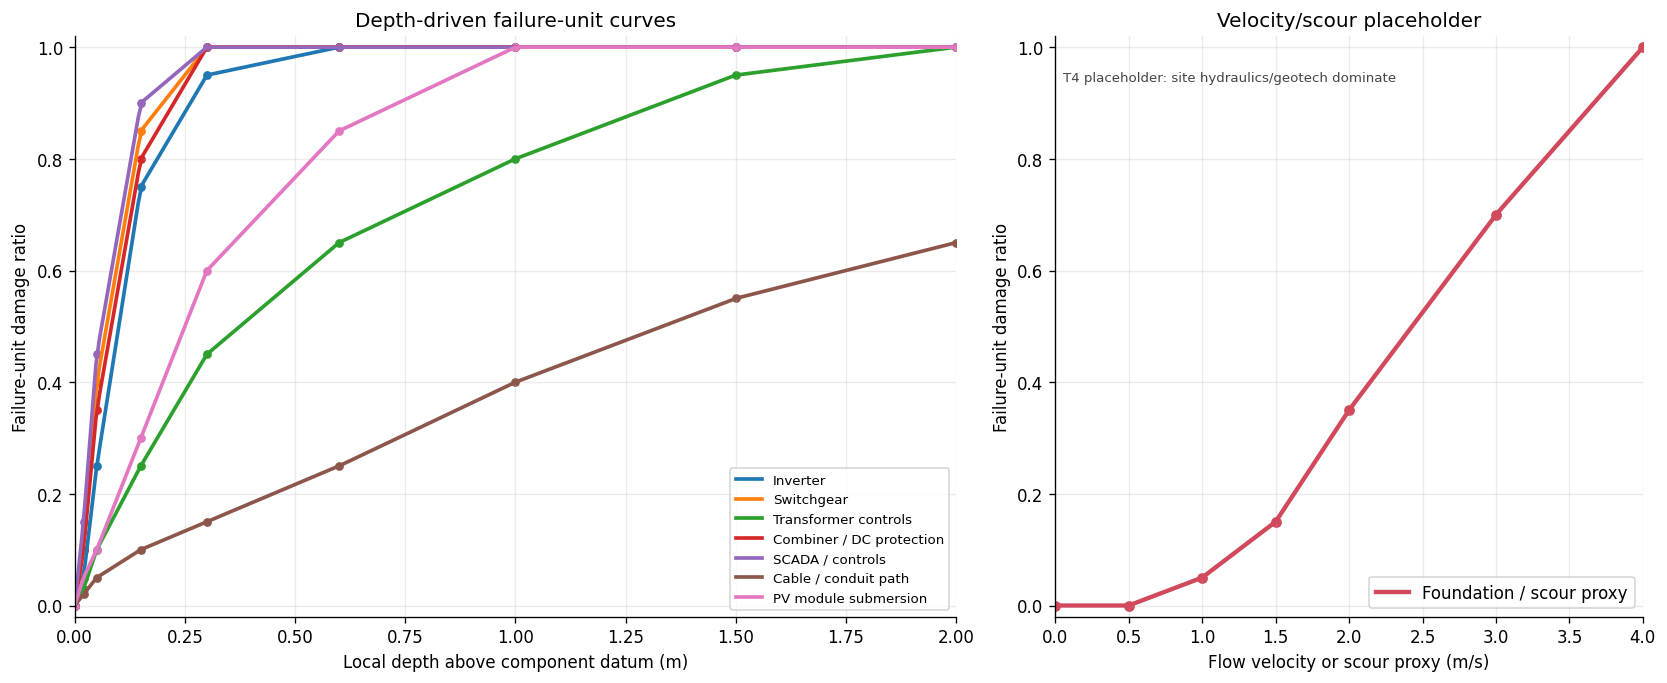

In [5]:
curve_labels = {
    "FS_INV": "Inverter",
    "FS_SWG": "Switchgear",
    "FS_XFMR": "Transformer controls",
    "FS_COMB": "Combiner / DC protection",
    "FS_SCADA": "SCADA / controls",
    "FS_CABLE": "Cable / conduit path",
    "FS_PVMOD": "PV module submersion",
    "FS_FOUND": "Foundation scour proxy",
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5.8), gridspec_kw={"width_ratios": [1.5, 1.0]})
ax = axes[0]
for rec in artifact["curve_records"]:
    if "flow_velocity" in rec["x_axis"] or "scour" in rec["x_axis"]:
        continue
    pts = np.asarray(rec["parameters"]["points"], dtype=float)
    x = np.linspace(pts[:, 0].min(), pts[:, 0].max(), 250)
    y = piecewise_dr(x, pts)
    ax.plot(x, y, lw=2.2, label=curve_labels.get(rec["failure_unit_id"], rec["failure_unit_id"]))
    ax.scatter(pts[:, 0], pts[:, 1], s=18)
ax.set_title("Depth-driven failure-unit curves")
ax.set_xlabel("Local depth above component datum (m)")
ax.set_ylabel("Failure-unit damage ratio")
ax.set_xlim(0, 2.0)
ax.set_ylim(-0.02, 1.02)
ax.legend(loc="lower right", fontsize=8)

ax = axes[1]
rec = curve_by_failure_unit["FS_FOUND"]
pts = np.asarray(rec["parameters"]["points"], dtype=float)
x = np.linspace(pts[:, 0].min(), pts[:, 0].max(), 250)
y = piecewise_dr(x, pts)
ax.plot(x, y, lw=2.6, color="#d1495b", label="Foundation / scour proxy")
ax.scatter(pts[:, 0], pts[:, 1], s=30, color="#d1495b")
ax.set_title("Velocity/scour placeholder")
ax.set_xlabel("Flow velocity or scour proxy (m/s)")
ax.set_ylabel("Failure-unit damage ratio")
ax.set_xlim(0, 4.0)
ax.set_ylim(-0.02, 1.02)
ax.legend(loc="lower right")
ax.text(0.05, 0.94, "T4 placeholder: site hydraulics/geotech dominate", fontsize=8, color="#444")

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "01_piecewise_runtime_curves.png", dpi=180, bbox_inches="tight")
plt.show()


## 5. Local-Depth Transform

This is the core spatial/elevation math for flood M3.

Preferred form:

```text
h_i = max(0, WSE - z_i_crit)
```

Where:

- `WSE` = event water surface elevation in a known vertical datum;
- `z_i_crit` = critical elevation for failure-unit `i`, such as cabinet entry, control section, module lower edge, or cable/pull-box pathway.

The plant can have one flood water level but many different local depths because components sit at different elevations.


In [6]:
WSE_M = 101.00
FLOW_VELOCITY_MPS = 1.6

# Illustrative asset substrate for demonstration only.
# Values and elevations must come from EPC/as-built/site survey/valuation data in a production run.
asset_rows = [
    {"failure_unit_id": "FS_INV", "component_critical_elevation_m": 100.72, "value_usd": 12_000_000, "fraction_value_exposed": 0.80, "metadata_note": "inverter skid/cabinet datum"},
    {"failure_unit_id": "FS_SWG", "component_critical_elevation_m": 100.84, "value_usd": 4_500_000, "fraction_value_exposed": 0.60, "metadata_note": "switchgear cabinet datum"},
    {"failure_unit_id": "FS_XFMR", "component_critical_elevation_m": 100.65, "value_usd": 8_000_000, "fraction_value_exposed": 0.50, "metadata_note": "transformer controls/terminals"},
    {"failure_unit_id": "FS_COMB", "component_critical_elevation_m": 100.55, "value_usd": 2_500_000, "fraction_value_exposed": 0.90, "metadata_note": "combiner/DC protection enclosures"},
    {"failure_unit_id": "FS_SCADA", "component_critical_elevation_m": 100.92, "value_usd": 1_200_000, "fraction_value_exposed": 0.40, "metadata_note": "SCADA/control cabinet"},
    {"failure_unit_id": "FS_CABLE", "component_critical_elevation_m": 100.35, "value_usd": 5_000_000, "fraction_value_exposed": 0.70, "metadata_note": "conduit/pull-box pathway"},
    {"failure_unit_id": "FS_PVMOD", "component_critical_elevation_m": 101.10, "value_usd": 55_000_000, "fraction_value_exposed": 0.30, "metadata_note": "module lower edge above WSE in this scenario"},
    {"failure_unit_id": "FS_FOUND", "value_usd": 7_000_000, "fraction_value_exposed": 0.50, "metadata_note": "uses velocity/scour proxy, not WSE"},
]

scenario = evaluate_scenario(asset_rows, water_surface_elevation_m=WSE_M, flow_velocity_mps=FLOW_VELOCITY_MPS)
scenario["local_intensity_label"] = np.where(
    scenario["x_axis"].str.contains("flow_velocity|scour", regex=True),
    scenario["local_intensity"].map(lambda x: f"{x:.2f} m/s"),
    scenario["local_intensity"].map(lambda x: f"{x:.2f} m"),
)

display(Markdown(f"**Illustrative event:** WSE = `{WSE_M:.2f} m`, flow velocity = `{FLOW_VELOCITY_MPS:.2f} m/s`."))
display(scenario[[
    "failure_unit_id", "component", "x_axis", "local_intensity_label", "failure_unit_damage_ratio",
    "value_usd", "fraction_value_exposed", "conditional_loss_if_event_usd", "metadata_note"
]].style.format({
    "failure_unit_damage_ratio": "{:.3f}",
    "value_usd": "${:,.0f}",
    "fraction_value_exposed": "{:.2f}",
    "conditional_loss_if_event_usd": "${:,.0f}",
}))


**Illustrative event:** WSE = `101.00 m`, flow velocity = `1.60 m/s`.

,failure_unit_id,component,x_axis,local_intensity_label,failure_unit_damage_ratio,value_usd,fraction_value_exposed,conditional_loss_if_event_usd,metadata_note
0,FS_INV,INVERTER,local_depth_above_component_datum_m,0.28 m,0.923,"$12,000,000",0.80,"$8,864,000",inverter skid/cabinet datum
1,FS_SWG,SWITCHGEAR,local_depth_above_component_datum_m,0.16 m,0.860,"$4,500,000",0.60,"$2,322,000",switchgear cabinet datum
2,FS_XFMR,TRANSFORMER_MAIN,local_depth_above_component_datum_m,0.35 m,0.483,"$8,000,000",0.50,"$1,933,333",transformer controls/terminals
3,FS_COMB,COMBINER_BOX + DC_PROTECTION,local_depth_above_component_datum_m,0.45 m,1.000,"$2,500,000",0.90,"$2,250,000",combiner/DC protection enclosures
4,FS_SCADA,MONITORING_SYSTEM,local_depth_above_component_datum_m,0.08 m,0.585,"$1,200,000",0.40,"$280,800",SCADA/control cabinet
5,FS_CABLE,CABLE_AC + CABLE_DC,depth_pathway_termination_exposure,0.65 m,0.269,"$5,000,000",0.70,"$940,625",conduit/pull-box pathway
6,FS_PVMOD,PV_MODULE,depth_above_module_lower_edge_m,0.00 m,0.000,"$55,000,000",0.30,$0,module lower edge above WSE in this scenario
7,FS_FOUND,FOUNDATION_BASE,flow_velocity_mps_or_scour_proxy,1.60 m/s,0.190,"$7,000,000",0.50,"$665,000","uses velocity/scour proxy, not WSE"


## 6. Visualize Component Elevation And Local Depth

This is the flood analogue to hail spatial exposure, but it is vertical/local rather than only areal.

A component above water has `h_i = 0` even if the site experiences flooding. A low cabinet or conduit pathway can have meaningful local depth under the same event.


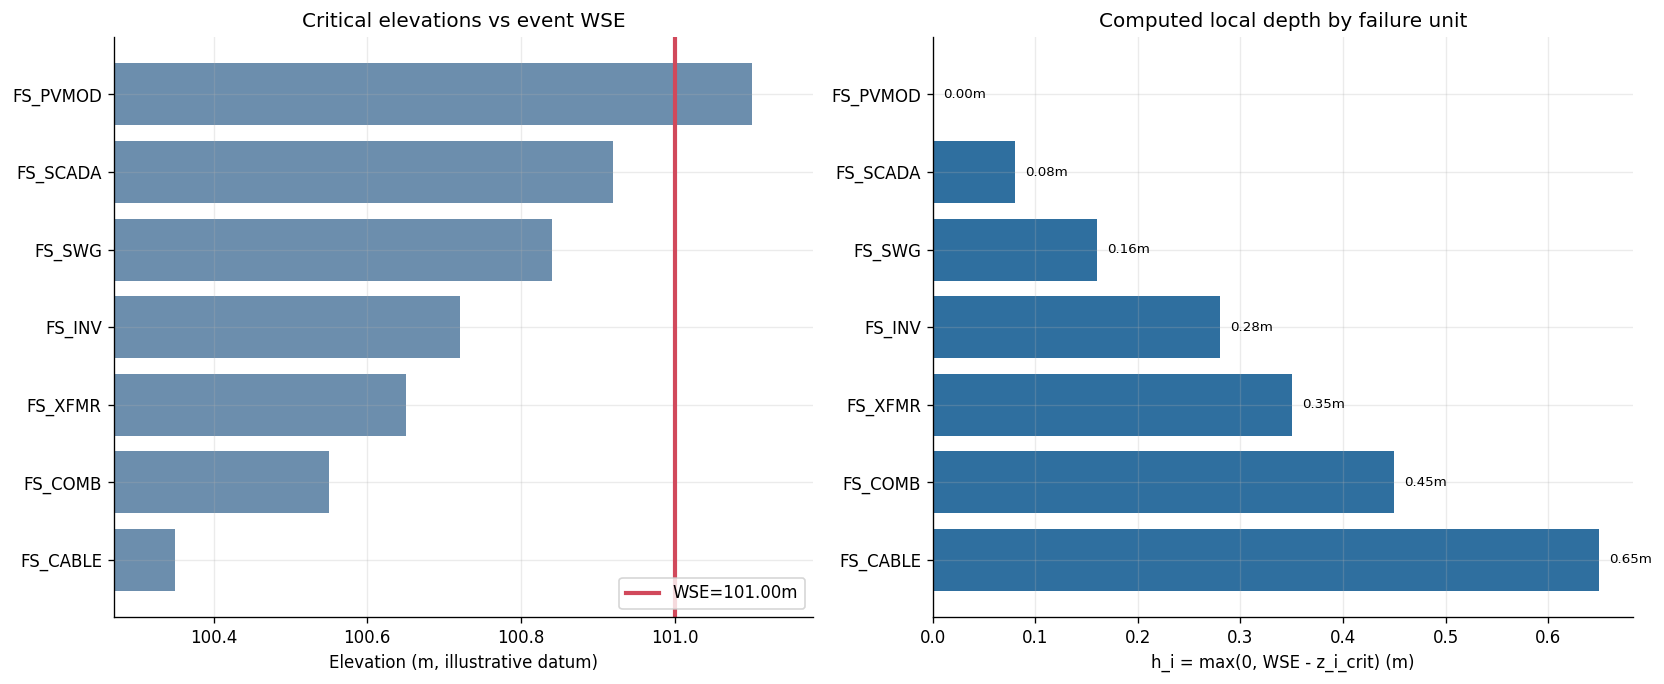

In [7]:
elev_df = pd.DataFrame([
    {
        "failure_unit_id": row["failure_unit_id"],
        "component_critical_elevation_m": row.get("component_critical_elevation_m", np.nan),
        "local_depth_m": local_depth_from_wse(WSE_M, row["component_critical_elevation_m"]) if "component_critical_elevation_m" in row else np.nan,
    }
    for row in asset_rows
    if row["failure_unit_id"] != "FS_FOUND"
]).merge(failure_units[["id", "component"]], left_on="failure_unit_id", right_on="id", how="left")

elev_df = elev_df.sort_values("component_critical_elevation_m")
fig, axes = plt.subplots(1, 2, figsize=(14, 5.8))
ax = axes[0]
ax.barh(elev_df["failure_unit_id"], elev_df["component_critical_elevation_m"], color="#6c8ead")
ax.axvline(WSE_M, color="#d1495b", lw=2.5, label=f"WSE={WSE_M:.2f}m")
ax.set_title("Critical elevations vs event WSE")
ax.set_xlabel("Elevation (m, illustrative datum)")
zoom_min = min(elev_df["component_critical_elevation_m"].min(), WSE_M) - 0.08
zoom_max = max(elev_df["component_critical_elevation_m"].max(), WSE_M) + 0.08
ax.set_xlim(zoom_min, zoom_max)
ax.legend(loc="lower right")

ax = axes[1]
ax.barh(elev_df["failure_unit_id"], elev_df["local_depth_m"], color="#2f6f9f")
ax.set_title("Computed local depth by failure unit")
ax.set_xlabel("h_i = max(0, WSE - z_i_crit) (m)")
for y, (_, row) in enumerate(elev_df.iterrows()):
    ax.text(row["local_depth_m"] + 0.01, y, f"{row['local_depth_m']:.2f}m", va="center", fontsize=8)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "01_local_depth_transform.png", dpi=180, bbox_inches="tight")
plt.show()


## 7. Conditional Loss Assembly

Once each failure-unit DR is evaluated, the consumer applies value and exposure:

```text
loss_i = DR_i * value_i * fraction_value_exposed_i
```

This is still conditional event loss. It is not EAL and not a return-period metric.


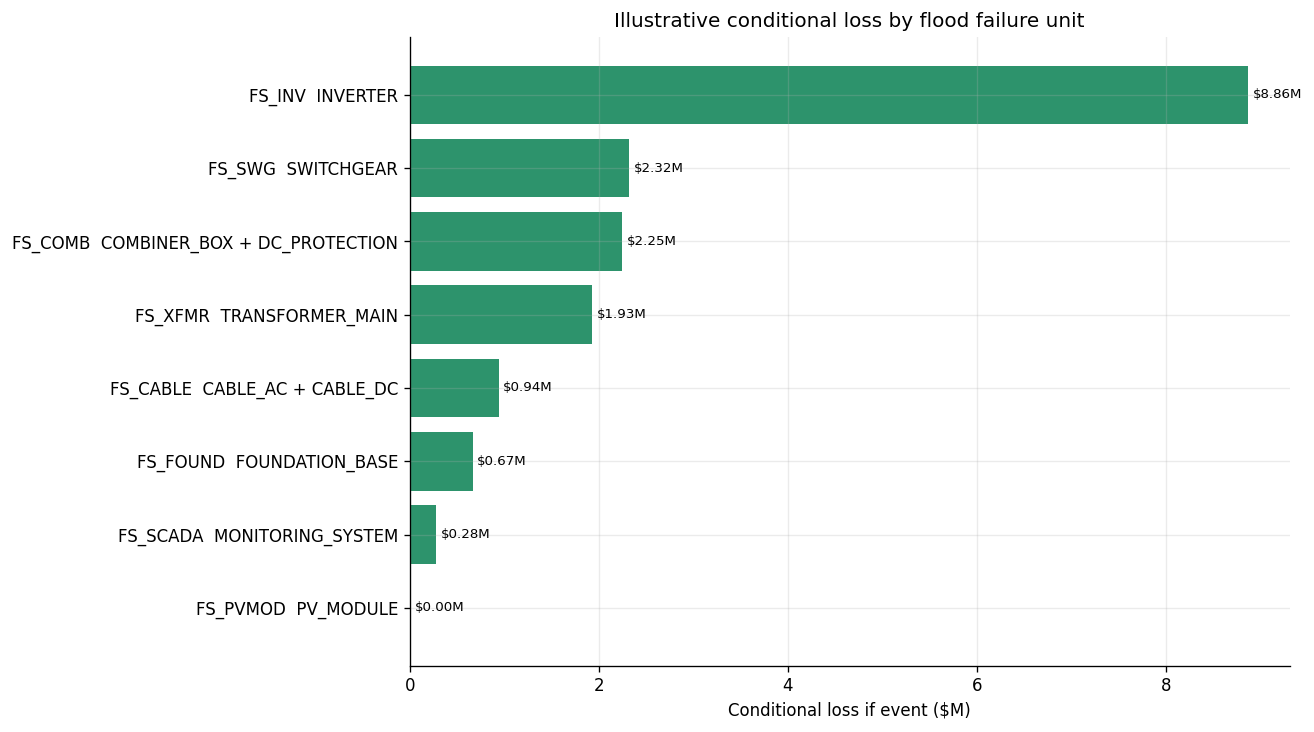

,metric,value
0,total_conditional_loss_if_event_usd,"$17,255,758"
1,total_value_basis_usd,"$95,200,000"
2,conditional_loss_fraction_of_value_basis,18.13%


In [8]:
scenario_sorted = scenario.sort_values("conditional_loss_if_event_usd", ascending=True)
fig, ax = plt.subplots(figsize=(11, 6.2))
ax.barh(
    scenario_sorted["failure_unit_id"] + "  " + scenario_sorted["component"],
    scenario_sorted["conditional_loss_if_event_usd"] / 1_000_000,
    color="#2d936c",
)
ax.set_title("Illustrative conditional loss by flood failure unit")
ax.set_xlabel("Conditional loss if event ($M)")
for y, (_, row) in enumerate(scenario_sorted.iterrows()):
    ax.text(row["conditional_loss_if_event_usd"] / 1_000_000 + 0.05, y, f"${row['conditional_loss_if_event_usd']/1_000_000:.2f}M", va="center", fontsize=8)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "01_conditional_loss_by_failure_unit.png", dpi=180, bbox_inches="tight")
plt.show()

summary = pd.DataFrame([
    {"metric": "total_conditional_loss_if_event_usd", "value": scenario["conditional_loss_if_event_usd"].sum()},
    {"metric": "total_value_basis_usd", "value": scenario["value_usd"].sum()},
    {"metric": "conditional_loss_fraction_of_value_basis", "value": scenario["conditional_loss_if_event_usd"].sum() / scenario["value_usd"].sum()},
])
display(summary.style.format({"value": lambda x: f"${x:,.0f}" if x > 1 else f"{x:.2%}"}))


## 8. Selectors, Conditioners, And Exposure

Flood uses the same architecture words as hail, but they show up differently:

- **Selectors**: fixed asset attributes such as enclosure rating or transformer type. Some are current flags; some are future curve variants.
- **Conditioners**: event-time or pathway state, such as conduit water path or shutdown/energized state.
- **Exposure**: `fraction_value_exposed`, the part of the value bucket actually in the flood swath or below waterline.

The local-depth transform is an exposure/axis bridge, not intrinsic equipment fragility.


In [9]:
display(Markdown("**Selectors**"))
display(pd.DataFrame(artifact["selector_logic"]))

display(Markdown("**Conditioners / axis bridges**"))
display(pd.DataFrame(artifact["conditioner_logic"]))

display(Markdown("**Exposure logic**"))
display(pd.DataFrame(artifact["exposure_logic"]))


**Selectors**

,field,aliases,required,effect,canonical
0,enclosure_rating,[equipment_ip_or_nema_rating],recommended,selects_curve_variant_or_flags_submersion_resistance,True
1,enclosure_rating_system,NaN,False,distinguishes NEMA versus IP rating basis,NaN
2,transformer_type,NaN,False,future transformer curve variant,NaN
3,cable_location_rating,[cable_wet_location_rating],False,future cable curve variant,NaN


**Conditioners / axis bridges**

,adjustment_id,field,adjustment_type,form,source_ids,tier,reasoning,open_seam
0,FLOOD_CONDUIT_PATH_FLAG_V1,conduit_water_path_present,open_seam_flag_or_variant_selection,flag; no universal numeric multiplier in v1.0,[DOE_FEMP_PV_FLOOD],T3_engineering_proxy_or_adjacent_empirical,Mechanism is source-supported but site-specific routing controls magnitude.,site conduit and pull-box layout
1,FLOOD_ELEVATION_SHIFT_V1,component_critical_elevation_m,horizontal_shift,"h_i = max(0, WSE - z_i_crit)","[DOE_FEMP_PV_FLOOD, FEMA_P348]",T2_public_lab_standard_or_physics,Elevation/freeboard changes local exposure rather than intrinsic fragility.,surveyed component datum


**Exposure logic**

,field,required,effect
0,fraction_value_exposed,True,scales affected value in flood swath


## 9. Parameter Tiers And Open Seams

Flood’s runtime curves are mostly T3 engineering parameterizations: the mechanisms and tabular form are source-supported, but exact percentages are not claims-calibrated.

The foundation velocity/scour proxy is T4 and should be treated as a placeholder unless backed by site hydraulic/geotechnical analysis.


,parameter,curve_id,param_role,tier,source_ids,reasoning,update_trigger
0,depth_damage_points,FS_INV,curve_fit_shape,T3_engineering_proxy_or_adjacent_empirical,"DOE_FEMP_PV_FLOOD, NEMA_GD1_2019, USACE_HEC_FIA",Mechanism and curve form are source-supported; exact percentages are engineering parameterization.,claims/OEM/forensic depth-damage data
1,depth_damage_points,FS_SWG,curve_fit_shape,T3_engineering_proxy_or_adjacent_empirical,"DOE_FEMP_PV_FLOOD, NEMA_GD1_2019, USACE_HEC_FIA",Mechanism and curve form are source-supported; exact percentages are engineering parameterization.,claims/OEM/forensic depth-damage data
2,depth_damage_points,FS_XFMR,curve_fit_shape,T3_engineering_proxy_or_adjacent_empirical,"DOE_FEMP_PV_FLOOD, NEMA_GD1_2019, USACE_HEC_FIA",Mechanism and curve form are source-supported; exact percentages are engineering parameterization.,claims/OEM/forensic depth-damage data
3,depth_damage_points,FS_COMB,curve_fit_shape,T3_engineering_proxy_or_adjacent_empirical,"DOE_FEMP_PV_FLOOD, NEMA_GD1_2019, USACE_HEC_FIA",Mechanism and curve form are source-supported; exact percentages are engineering parameterization.,claims/OEM/forensic depth-damage data
4,depth_damage_points,FS_SCADA,curve_fit_shape,T3_engineering_proxy_or_adjacent_empirical,"DOE_FEMP_PV_FLOOD, NEMA_GD1_2019, USACE_HEC_FIA",Mechanism and curve form are source-supported; exact percentages are engineering parameterization.,claims/OEM/forensic depth-damage data
5,depth_damage_points,FS_CABLE,curve_fit_shape,T3_engineering_proxy_or_adjacent_empirical,"DOE_FEMP_PV_FLOOD, NEMA_GD1_2019, USACE_HEC_FIA",Mechanism and curve form are source-supported; exact percentages are engineering parameterization.,claims/OEM/forensic depth-damage data
6,depth_damage_points,FS_PVMOD,curve_fit_shape,T3_engineering_proxy_or_adjacent_empirical,"DOE_FEMP_PV_FLOOD, NEMA_GD1_2019, USACE_HEC_FIA",Mechanism and curve form are source-supported; exact percentages are engineering parameterization.,claims/OEM/forensic depth-damage data
7,foundation_velocity_scour_points,FS_FOUND,open_seam_placeholder,T4_placeholder_or_expert_judgment,ANZGEO_2023_SCOUR_CONTEXT,Scour is site-geotechnical; generic velocity proxy is retained only as conditional placeholder.,hydraulic/geotechnical model or forensic scour dataset
8,local_depth_transform,all_depth_curves,axis_bridge,T2_public_lab_standard_or_physics,"DOE_FEMP_PV_FLOOD, FEMA_P348",Component freeboard/elevation controls local exposure.,none; replace only if cell axis changes


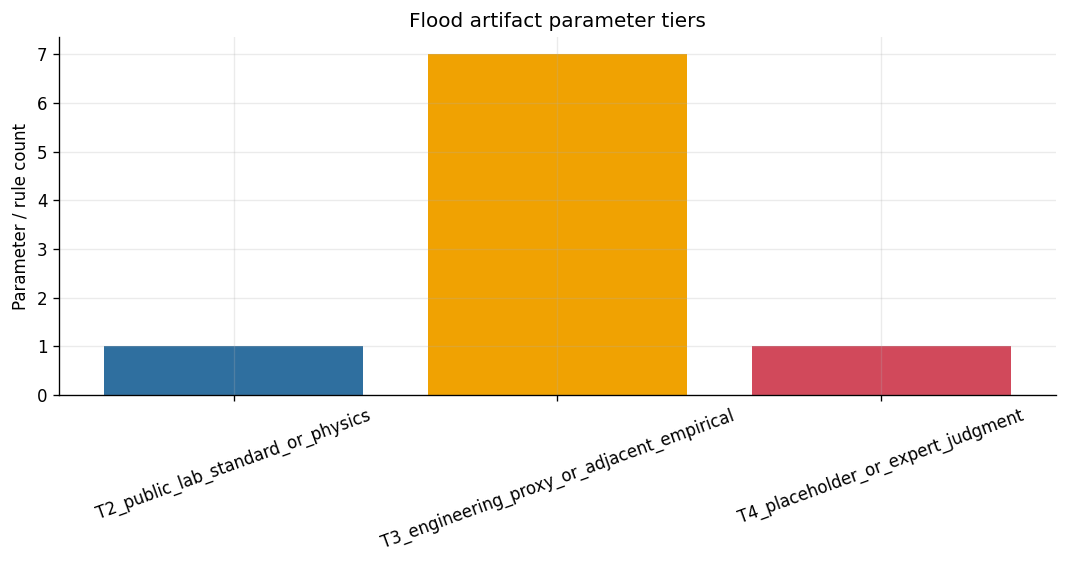

In [10]:
param_tiers = pd.DataFrame(artifact["parameter_tier_table"])
param_tiers["source_ids"] = param_tiers["source_ids"].apply(lambda xs: ", ".join(xs))
display(param_tiers[["parameter", "curve_id", "param_role", "tier", "source_ids", "reasoning", "update_trigger"]])

tier_counts = param_tiers.groupby("tier").size().reset_index(name="count")
fig, ax = plt.subplots(figsize=(9, 4.8))
colors = {"T2_public_lab_standard_or_physics": "#2f6f9f", "T3_engineering_proxy_or_adjacent_empirical": "#f0a202", "T4_placeholder_or_expert_judgment": "#d1495b"}
ax.bar(tier_counts["tier"], tier_counts["count"], color=[colors.get(t, "#999") for t in tier_counts["tier"]])
ax.set_title("Flood artifact parameter tiers")
ax.set_ylabel("Parameter / rule count")
ax.tick_params(axis="x", labelrotation=20)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "01_parameter_tier_counts.png", dpi=180, bbox_inches="tight")
plt.show()


## 10. Capability Declaration

The flood artifact supports failure-unit scalar DR and scenario loss with explicit value/exposure basis.

It also populates deterministic piecewise/state tables, but those tables are not uncertainty distributions. Therefore PML, VaR, and TVaR remain withheld by this damage artifact.


In [11]:
cap = artifact["capability_declaration"]
display(pd.DataFrame([
    {"metric_or_emit": key, "status": value}
    for key, value in cap["metrics_supportable"].items()
]))

display(pd.DataFrame([
    {"field": key, "value": value}
    for key, value in cap["cap_binding"].items()
]))

display(Markdown("**Emit contract**"))
display(pd.DataFrame([artifact["emit_contract"]]))


,metric_or_emit,status
0,failure_unit_scalar_dr,supported
1,scenario_loss_given_value_basis,supported_with_explicit_value_and_exposure_basis
2,scalar_eal,conditional_require_cap_binding_preflight
3,pml,withheld_no_tail_distribution
4,var,withheld_no_tail_distribution
5,tvar,withheld_no_tail_distribution


,field,value
0,policy,fail_closed
1,preflight_status,not_executed_no_downstream_frequency_or_state_distribution
2,required_before_scalar_eal,True
3,tolerance_pct,2.5
4,action_if_fail,require_mean_plus_spread_emit
5,reason,Current package contains severity curves but not downstream hazard/state distributions or project-specific cap tests.


**Emit contract**

,schema_version,supported_emit_modes,populated_emit_modes_for_this_cell,primary_grain,distribution_fields_present_even_when_null,discrete_state_table_note
0,damage_emit.v1,"[scalar_mean, scalar_mean_plus_bounds, discrete_state_table, parametric_distribution, state_ensemble]","[scalar_mean, discrete_state_table]",failure_unit,True,"Piecewise depth-damage ordinates are deterministic state/curve tables, not uncertainty distributions."


## 11. What This Notebook Teaches

Flood x solar is where the architecture starts paying off:

- one cell can contain many failure-unit records;
- each unit can have its own x-axis basis;
- local depth/elevation creates the right component-level intensity;
- value/exposure assembly happens after DR evaluation;
- placeholders and open seams are visible instead of hidden in a plant-level curve.

The next useful notebook is `00_curve_curation_walkthrough.ipynb` for flood. That should explain the evidence and curation choices behind the piecewise ordinates in more detail.
